In [4]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()#array with labels this are feature of data

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [5]:
X, y = mnist["data"],mnist["target"]#defining X and y through columns
print(X.shape)
print(y.shape)
#there are 70,000 images and each image has 784 features
#784 mean 28*28 as each image is of 28*28 pixel
#each pixel is equal to 1 features and each pixel intensity range between 0(white) to 255(black)


(70000, 784)
(70000,)


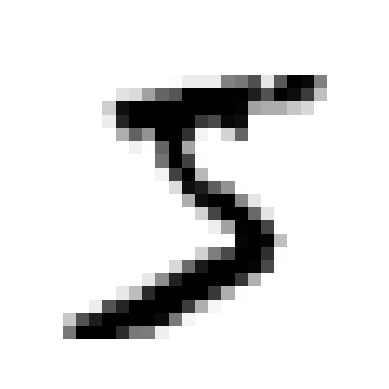

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
some_digit = X.iloc[0].to_numpy()#keep in mind
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [7]:
y[0]

'5'

In [8]:
type(y[0]) # ITS string

str

In [9]:
#str to int
import numpy as np
y = y.astype(np.uint8)
print(type(y[0]))

<class 'numpy.uint8'>


In [10]:
#splititng data into train and test
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]


<h4>Binary Classifier</h4>
this jsut classifiy between 5 and non-5 thatw it 


In [12]:
y_train_5 = (y_train == 5) #true for all 5s , train , we set y_Train == 5 only doing only for 5
y_test_5 = (y == 5) #test

<h4>SGD classifier</h4>

- best for online learning
- handle large datasets efficiently
- it learn by updating weights step by step on small chunks of data instead of whole data at once


In [14]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_5)#we are taking whole training set and keeping target only 5 
#as we are using y_Train_5 dataset

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [15]:
sgd_clf.predict([some_digit])#some digit = 5
#As some digit is referring to digit five and after training the model, we can see that 
#the is true that the digit is five and a model is successfully trained and it's giving 
#the right output. If we change the index to someone else visit, the model will give so 
#it's correct.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

<h3>Performance Measures</h3>
this a bit lenghty part and hard compare to regressor 
<br>
⬇<br>
Measuring Accuracy Using Cross - Validation<br>
⬇<br>

In [17]:
#implementation of Cross-validation manual
#we need more command
from sklearn.model_selection import StratifiedKFold
#it splits dataset while preserving class ratio , ratio of dataset is equal to ratio on each class
from sklearn.base import clone
#we use clone so that every fold start with fresh model,if dont model contain previous learnign also
#in cv each fold train on new model and test 

skfolds = StratifiedKFold(n_splits = 3, random_state=42, shuffle = True)
                        # dataspliting                  data suffle before spliting
# 3 -  fold cross validation 
for train_index, test_index in skfolds.split(X_train, y_train_5):
                                    #the loop run 3 times ans skflods = 3
    #cloning the model for cv 
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.iloc[train_index]#using iloc we are selecting rows
    y_train_folds = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)#training the model
                    #input        target
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))#accuracy formula
    #selecting rows by indexing number by using df.iloc[]
    #instead of training once dataset is split into 3 times and tested each time so train on two folds and test on folds
    #3 - result this is accuracy by each folds

0.9669
0.91625
0.96785


In [18]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [19]:
from sklearn.base import BaseEstimator
#BaseEstimator is base class from sklearn
#making class for that target not 5
class Never5Classifier(BaseEstimator):#defining own ml model, mean model that never predicted 5
    def fit(self, X, y=None): # this fit model and model will learn and return a model then knows this data
        return self
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [20]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

<h4>Confusion Matrix</h4>
a much better way to evaluate performance of classifier is look a <i>confusion matrix</i>
<br>

1. use to get how much model do correct prediction
2. how much it does wrong prediction
3. Actual labels and Model predictions and then compare them

In [22]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

<h4>
    Confusion Matrix
</h4>

- best way to evalulate preformance
- need set of prediction so that it can compute with target values
- cross_val_predict for predicting for each data points
- prediction data points and actual target values combine and form cofficient matrix




In [24]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [25]:
#acutal valeus = y_train_5
#predict values = y_train_pred
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5, y_train_pred)
#53k predict (not - 5) right as
#1891 wrongly classified as 5  -- should be zero
#3530 correctly classified as 5 

array([[53892,   687],
       [ 1891,  3530]])

In [26]:
y_train_prefect_predict = y_train_5
confusion_matrix(y_train_5, y_train_prefect_predict)

array([[54579,     0],
       [    0,  5421]])

<i>precision</i>  = TP / TP + FP
<br>
<i>recall</i> = TP / TP +FN - this are positive instance that are correctly predicted 
<br>

![screenshot](Confusion_Matrix.png)

In [28]:
#precision and recall
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_train_5, y_train_pred) 
recall = recall_score(y_train_5, y_train_pred)
print(precision*100)
print(recall*100)
#83% correctly identified 5's 
#65% correctly classified them

83.70879772350011
65.11713705958311


to compare between two classes use <b>F1 score</b> 
<br>

- it add weigths to lower values
- F1 = 2 * (precision * recall) / (precision + recall)

In [30]:
#call f1_score() fucntion
from sklearn.metrics import f1_score
print(f1_score(y_train_5, y_train_pred)*100)

73.25171197343847


In [31]:
#now seting threshold in model for prediction
y_scores = sgd_clf.decision_function([some_digit])
y_scores
#decision_function return score of data point 
#predict() - yes or no

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([2164.22030239])

In [32]:
threshold = 2164
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred
#threshold = 8000 it show Flase
#threshold = 2164 it show True
"""
Basically, the decision_function give a probability score for given data point that 
how much probality it is 5 or not, so if we set threshold(2164) greater than that it's a
FALSE  and if we set the threshold lower than that, it's a TRUE so the above code is 
for a particular data point with the image is 5
"""

"\nBasically, the decision_function give a probability score for given data point that \nhow much probality it is 5 or not, so if we set threshold(2164) greater than that it's a\nFALSE  and if we set the threshold lower than that, it's a TRUE so the above code is \nfor a particular data point with the image is 5\n"

In [33]:
#to find right threshold
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, 
                             method="decision_function")
#gives score of all instance

In [34]:
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447])

In [35]:
#now to compute prediction recall curve function for threshold
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

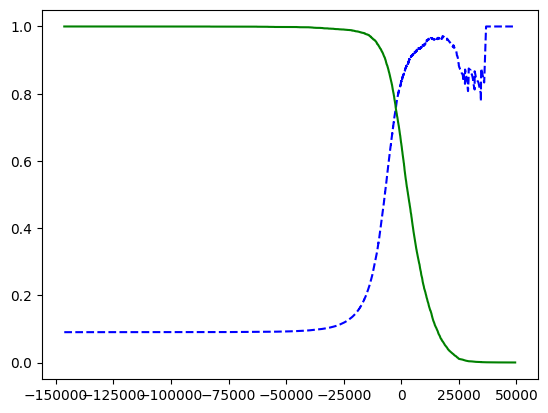

In [36]:
#plt diagram
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recalls")
    [...]
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

In [37]:
threshold_90 = thresholds[np.argmax(precisions >= 0.90)]
threshold_90

3370.019499144183

In [38]:
#for now 
y_train_90 = (y_scores >= threshold_90)
print(precision_score(y_train_5, y_train_90)*100)
print(recall_score(y_train_5, y_train_90)*100)
#very low recall


90.00345901072293
47.99852425751706


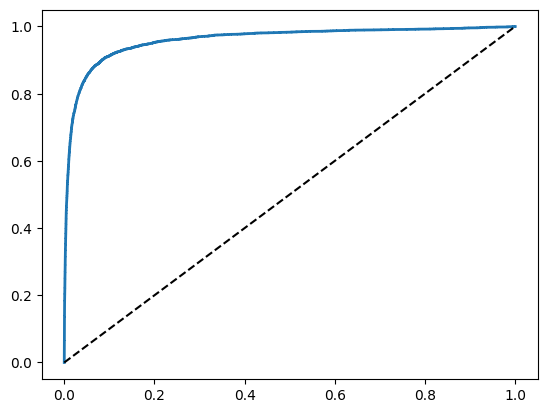

In [39]:
#ploting roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)#it calculate 

def plot_roc_curve(fpr, tpr, label = None):
    plt.plot(fpr, tpr, linewidth=2, label = label)
    plt.plot([0,1], [0, 1], 'k--')
    [...]
plot_roc_curve(fpr, tpr)
plt.show()

In [85]:
#for comparing  classifier area under curve is best way to 
#for prefect classifier AUC ROC = 1 
#for random classifier it has 0.5
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_train_5, y_scores)*100)
"""
for fasle positive - use PR curve
otherwise use ROC curve"""


96.04938554008616


'\nfor fasle positive - use PR curve\notherwise use ROC curve'

<h3>Random Forest</h3>
Now train model on <b>RandomForestClassifier</b>  and then compare its ROC with SGDClassifier<br>

here we have `predict_proba()` that basically return an array of each instance containing probability that given instance belong to given class 

In [42]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")

In [43]:
y_scores_forest = y_probas_forest[:,1] #for positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

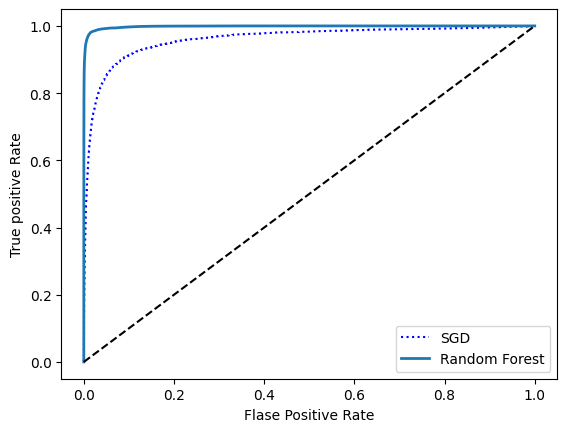

In [79]:
plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc = "lower right")
plt.xlabel("Flase Positive Rate")
plt.ylabel("True positive Rate")
plt.show()

In [89]:
roc_auc_score(y_train_5, y_scores_forest)*100


99.83296721818179

Better than |SGD 

<h3>Multiclass Classification</h3>

- distinguish between more than two classes
- model compatible = SGD classifier, Random Forest classifier and naive Bayers
- <b>one versus the rest</b> -hear the actual thing is, if we use a binary classification to detect 10 images. Then we have to make <B>10 different classes</b> that detect from 0 to 9 and then each classifier will detect a single image like classifier  a -  detect 0, classifier  b-  detect 1, and so and when we want output, then we have to choose  score from each classifier, get a decision scores from each classifier and for that image the highest score,
- like image that has 5 and that image will go through 10 different classes, and then each classifier give their decision score, and the highest one we will choose.
- <b>one verus one</b> - N classes and need to train N(N - 1)/2 classifier.
- in one versus one, the thing is you have to train so many times like for <b>10 classes. We need to train 45 binary classifiers,</b> so it's a huge computational loss but the thing is here we have to train only one part of data like 0 & 1. If it's not complete, then 1 or 2, if it's not finish.
- another thing is some classify preferred training on small data set, not on a large data set support vector machine classified. BUt other prefer OvR


<h3>Support Vector Machine Classifier</h3>

In [100]:
from sklearn.svm import SVC
svm_clf = SVC()
svm_clf.fit(X_train, y_train)
svm_clf.predict([some_digit]) #that's 5
#train on whole data not as 5 or non 5


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([5], dtype=uint8)

In [102]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores
"""this is function written 10 array scores, so that represent the probability that
by each class that image is Fine, whichever class represent highest score. That's 
correct."""

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [108]:
np.argmax(some_digit_scores)

5

In [112]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [114]:
svm_clf.classes_[5]

5

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(X_train, y_train)
